# Email Spam Detection with Machine Learning

## Objective
Build a Natural Language Processing (NLP) model to classify messages as Spam or Ham.

In [3]:
import pandas as pd

In [4]:
df = pd.read_csv(
    "data/SMSSpamCollection",
    sep="\t",
    header=None,
    names=["label", "message"]
)

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [6]:
df.shape

(5572, 2)

In [7]:
df.columns

Index(['label', 'message'], dtype='str')

In [8]:
df.isnull().sum()

label      0
message    0
dtype: int64

In [6]:
df["label"].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

In [7]:
df["label"].value_counts(normalize=True) * 100

label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64

In [8]:
!pip install nltk


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: C:\Users\rilah\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [9]:
import nltk

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rilah\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [5]:
import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

In [12]:
%pip install nltk

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
sample_text = "Congratulations! You have WON a FREE prize!!!"

print("Original:")
print(sample_text)

print("\nAfter preprocessing:")
print(preprocess_text(sample_text))

Original:
Congratulations! You have WON a FREE prize!!!

After preprocessing:
congratulations free prize


In [6]:
df["clean_message"] = df["message"].apply(preprocess_text)

df[["message", "clean_message"]].head()

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though


## TF-IDF Feature Extraction

TF-IDF stands for Term Frequency-Inverse Document Frequency.

It converts text messages into numerical features that machine learning models can understand.

- **Term Frequency (TF):** Measures how frequently a word appears in a message.
- **Inverse Document Frequency (IDF):** Gives less importance to words that appear in many messages and more importance to words that are relatively rare.
- **TF-IDF:** Combines TF and IDF to assign an importance score to each word.

In this project, TF-IDF is used to convert the cleaned SMS messages into numerical feature vectors for machine learning.

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X = tfidf.fit_transform(df["clean_message"])

print("TF-IDF matrix shape:", X.shape)

TF-IDF matrix shape: (5572, 5000)


In [1]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
from sklearn.model_selection import train_test_split

y = df["label"].map({"ham": 0, "spam": 1})

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 4457
Testing samples: 1115


In [9]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

In [10]:
nb_model.fit(X_train, y_train)

print("Naive Bayes model trained successfully!")

Naive Bayes model trained successfully!


In [12]:
y_pred_nb = nb_model.predict(X_test)

print("Predictions completed!")

Predictions completed!


In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)

print("Naive Bayes Results")
print("-------------------")
print(f"Accuracy : {accuracy_nb:.4f}")
print(f"Precision: {precision_nb:.4f}")
print(f"Recall   : {recall_nb:.4f}")
print(f"F1-Score : {f1_nb:.4f}")

Naive Bayes Results
-------------------
Accuracy : 0.9731
Precision: 1.0000
Recall   : 0.7987
F1-Score : 0.8881


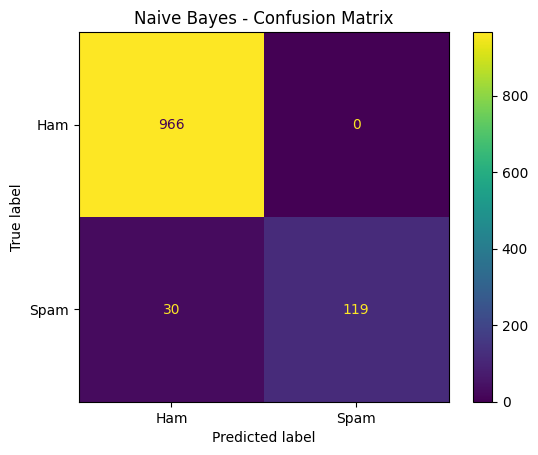

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_nb = confusion_matrix(y_test, y_pred_nb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=["Ham", "Spam"]
)

disp.plot()
plt.title("Naive Bayes - Confusion Matrix")
plt.show()

In [14]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

In [15]:
lr_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [16]:
y_pred_lr = lr_model.predict(X_test)

print("Predictions completed!")

Predictions completed!


In [17]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print("Logistic Regression Results")
print("---------------------------")
print(f"Accuracy : {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall   : {recall_lr:.4f}")
print(f"F1-Score : {f1_lr:.4f}")

Logistic Regression Results
---------------------------
Accuracy : 0.9641
Precision: 1.0000
Recall   : 0.7315
F1-Score : 0.8450


In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [23]:
%pip install matplotlib

     ---------------------------------------- 0.0/80.3 kB ? eta -:--:--
     ---------------------------------------- 0.0/80.3 kB ? eta -:--:--
     ----- ---------------------------------- 10.2/80.3 kB ? eta -:--:--
     ----- ---------------------------------- 10.2/80.3 kB ? eta -:--:--
     -------------- ----------------------- 30.7/80.3 kB 186.2 kB/s eta 0:00:01
     ------------------- ------------------ 41.0/80.3 kB 217.9 kB/s eta 0:00:01
     ----------------------------- -------- 61.4/80.3 kB 328.2 kB/s eta 0:00:01
     -------------------------------------- 80.3/80.3 kB 298.0 kB/s eta 0:00:00
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ---------------------------------------- 0.0/127.4 kB ? eta -:--:--
     --------------------- ----------------- 71.7/127.4 kB 2.0 MB/s eta 0:00:01
     -------------------------------------- 127.4/127.4 kB 1.5 MB/s eta 0:00:00
  Using cached pyp


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


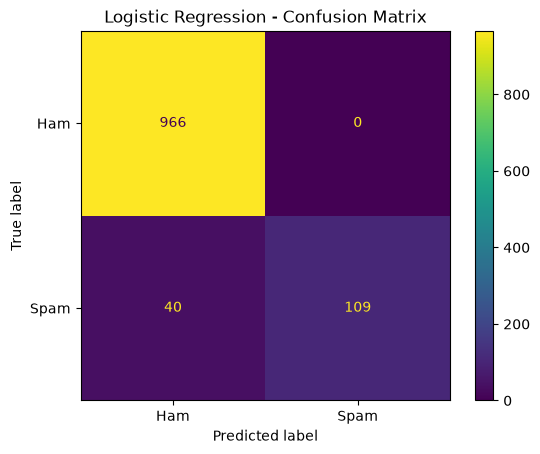

In [25]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=["Ham", "Spam"]
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

## Model Comparison

Two machine learning classifiers were trained and evaluated:

1. Multinomial Naive Bayes
2. Logistic Regression

For spam detection, recall is particularly important because it measures how many actual spam messages are successfully detected.

In [25]:
comparison = pd.DataFrame({
    "Model": ["Multinomial Naive Bayes", "Logistic Regression"],
    "Accuracy": [accuracy_nb, accuracy_lr],
    "Precision": [precision_nb, precision_lr],
    "Recall": [recall_nb, recall_lr],
    "F1-Score": [f1_nb, f1_lr]
})

comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Multinomial Naive Bayes,0.973094,1.0,0.798658,0.888060
1,Logistic Regression,0.964126,1.0,0.731544,0.844961


## Why is Recall Important for Spam Detection?

Recall is particularly important in spam detection because it measures how many of the actual spam messages are correctly identified by the model.

A false negative occurs when a spam message is incorrectly classified as a legitimate (ham) message. This means the spam message may reach the user's inbox.

A model with higher recall can identify more of the actual spam messages and reduce the number of spam messages that are missed.

In this project, Multinomial Naive Bayes achieved higher recall than Logistic Regression. Therefore, Naive Bayes is the better model for detecting spam based on recall.

However, precision is also important because incorrectly classifying legitimate messages as spam can cause important messages to be missed.

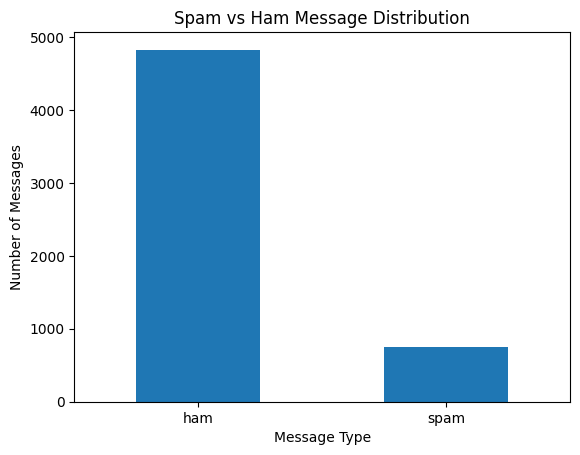

In [26]:
import matplotlib.pyplot as plt

df["label"].value_counts().plot(kind="bar")

plt.title("Spam vs Ham Message Distribution")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")
plt.xticks(rotation=0)
plt.show()

In [26]:
def predict_message(message):
    cleaned_message = preprocess_text(message)
    message_tfidf = tfidf.transform([cleaned_message])
    prediction = nb_model.predict(message_tfidf)[0]

    if prediction == 1:
        return "Spam"
    else:
        return "Ham"

In [27]:
test_messages = [
    "Congratulations! You won a free lottery prize. Claim now!",
    "Hey, are you coming to college tomorrow?",
    "URGENT! You have won a cash prize. Call now!",
    "Can you send me the notes when you are free?"
]

for message in test_messages:
    print("Message:", message)
    print("Prediction:", predict_message(message))
    print("-" * 60)

Message: Congratulations! You won a free lottery prize. Claim now!
Prediction: Spam
------------------------------------------------------------
Message: Hey, are you coming to college tomorrow?
Prediction: Ham
------------------------------------------------------------
Message: URGENT! You have won a cash prize. Call now!
Prediction: Spam
------------------------------------------------------------
Message: Can you send me the notes when you are free?
Prediction: Ham
------------------------------------------------------------


In [28]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_nb, target_names=["Ham", "Spam"]))

              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       966
        Spam       1.00      0.80      0.89       149

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.94      1115
weighted avg       0.97      0.97      0.97      1115



In [29]:
!pip install wordcloud

  Using cached wordcloud-1.9.6-cp311-cp311-win_amd64.whl.metadata (3.5 kB)
Using cached wordcloud-1.9.6-cp311-cp311-win_amd64.whl (306 kB)



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


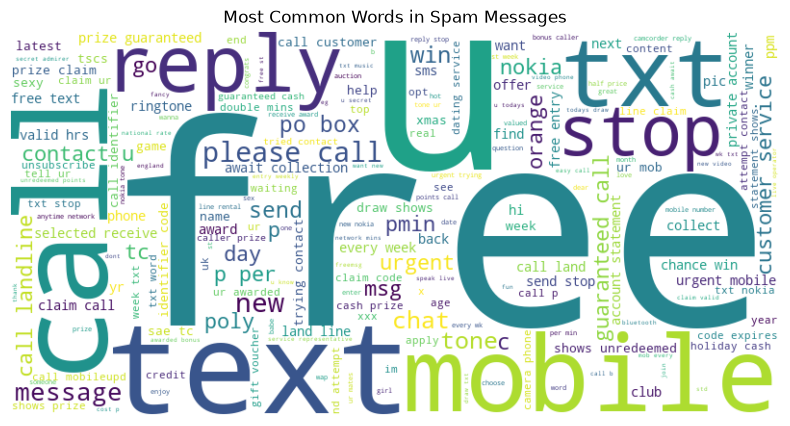

In [30]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

spam_text = " ".join(
    df[df["label"] == "spam"]["clean_message"]
)

spam_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(spam_text)

plt.figure(figsize=(10, 5))
plt.imshow(spam_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in Spam Messages")
plt.show()

## Conclusion

In this project, a Natural Language Processing (NLP) based machine learning system was developed to classify SMS messages as Spam or Ham.

The messages were cleaned using lowercase conversion, punctuation removal, and stopword removal. TF-IDF was then used to convert the text into numerical features.

Two machine learning models were trained:

- Multinomial Naive Bayes
- Logistic Regression

Both models were evaluated using accuracy, precision, recall, F1-score, and confusion matrix.

Based on the evaluation results, Multinomial Naive Bayes performed better than Logistic Regression for this dataset, particularly in terms of recall and F1-score. Therefore, Multinomial Naive Bayes was selected as the preferred model for spam detection.

The model was also tested on new messages and successfully classified example messages as Spam or Ham.

The WordCloud visualizations provided additional insight into commonly occurring words in spam and ham messages.